# **UNIVERSIDAD NACIONAL DE ROSARIO**
# **FACULTAD DE CIENCIAS EXACTAS, INGENIERÍA Y AGRIMENSURA**
# **TECNICATURA UNIVERSITARIA EN INTELIGENCIA ARTIFICIAL**  
## MINERÍA DE DATOS - TRABAJO PRÁCTICO N° 1  
### **INTEGRANTES:** Grimaldi, Damián (G-5977/3) | Alvarez, Fabián (A-4501/2)
### **Fecha de Entrega:** 2/10/2026

# Objetivo

El objetivo de este trabajo práctico es integrar los conocimientos adquiridos en las unidades 2 y 3 en un problema real asociado a especies de pingüinos.

# Librerías a utilizar

In [48]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import plotly.express as px
import seaborn as sns
import warnings

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

# sklearn
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

# Algoritmos de clustering
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import dendrogram, linkage

# Métricas
from sklearn.metrics import silhouette_score,silhouette_samples

# 1. Análisis exploratorio de datos (EDA)

In [49]:
url = 'https://raw.githubusercontent.com/fabianalvarez7/TUIA-Mineria-de-datos/master/TP1/penguins_size.csv'
pinguinos = pd.read_csv(url, sep=';') # Se especifica el separador ';'
pinguinos.head()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,NaN,NaN
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,NaN,NaN
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,NaN,NaN


In [50]:
pinguinos.tail()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
342,Gentoo penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
343,Gentoo penguin,46.8,14.3,215.0,4850.0,FEMALE,NaN,NaN
344,Gentoo penguin,50.4,15.7,222.0,5750.0,MALE,NaN,NaN
345,Gentoo penguin,45.2,14.8,212.0,5200.0,FEMALE,NaN,NaN
346,Gentoo penguin,49.9,16.1,213.0,5400.0,MALE,NaN,NaN


# Dataset

Se utiliza el dataset de penguins_size.csv.

Especie: Nuestra variable objetivo, es de tipo String, que cuenta con 3 tipos de pinguinos distintos.

Longuitud Culmen (mm): variable numérica, que nos indica el largo del pico.

Profundidad Culmen(mm): variable numérica, que nos indica la altura/profundidad del pico.

Longitud Aleta (mm): variable numérica, que nos indica la longuitud de la aleta de los diversos pingüinos.

Masa coporal (g) : variable numérica, que nos indica el peso del pingüino.

Sexo: Varibale categórica, indica MALE o FEMALE.

In [51]:
pinguinos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), object(2)
memory usage: 21.8+ KB


El dataset contiene un total de 347 filas y 8 columnas. La única columna completa es la de Especie, las demás presentan elementos faltantes. Las columnas 6 y 7 se encuentran completamente vacías, por lo tanto se eliminan.

In [52]:
# se eliminan las columnas vacías
pinguinos.drop(columns= ["Unnamed: 6", "Unnamed: 7"], inplace=True)
pinguinos.head()

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE


## Variables numéricas

In [53]:
pinguinos.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,345.000000,345.000000,345.000000,345.000000
mean,43.944348,17.155072,200.944928,4203.985507
std,5.510041,1.967138,14.106113,806.232797
min,32.100000,13.100000,172.000000,2700.000000
25%,39.200000,15.600000,190.000000,3550.000000
50%,44.400000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


Interpretación:

Longitud Culmen (mm)

- Media: 43.94 | Mediana: 44.40
- Rango: 32.1 – 59.6
- Baja dispersión (std ≈ 5.51)
- Distribución bastante simétrica, sin grandes valores extremos

Profundidad Culmen (mm)

- Media: 17.15 | Mediana: 17.30
- Rango: 13.1 – 21.5
- Variabilidad baja (std ≈ 1.97)
- Distribución equilibrada, sin sesgos marcados

Longitud Aleta (mm)

- Media: 200.94 | Mediana: 197.00
- Rango: 172 – 231
- Dispersión moderada (std ≈ 14.10)
- Ligera asimetría hacia valores altos

Masa corporal (g)

- Media: 4203.99 | Mediana: 4050.00
- Rango: 2700 – 6300
- Alta variabilidad (std ≈ 806.23)
- Leve asimetría positiva, con valores altos que elevan la media

##Relación entre variables numéricas

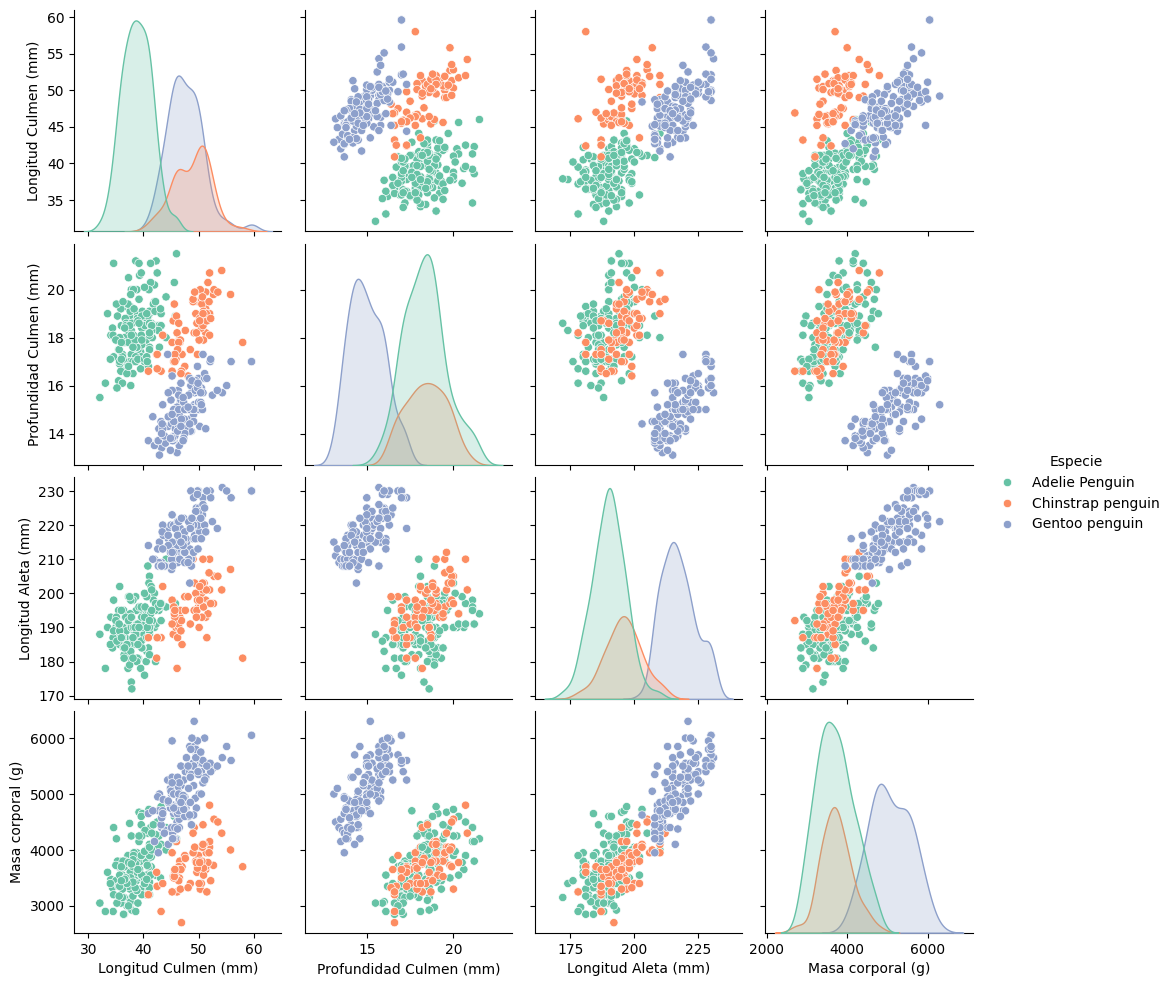

In [54]:
sns.pairplot(pinguinos, hue='Especie', palette='Set2')
plt.show()

Interpretación
- Las especies se distinguen bien visualmente. Gentoo es la más fácil de indentificar: tiene aletas más largas, mayor masa corporal y picos menos profundos que las otras especies.
- Adelie y Chinstrap se parecen más entre sí.
- Se observa una relación positiva entre algunas variables, como Longitud de aleta (mm) y Masa corpotal (g) por ejemplo.
- No se ven valores atípicos extremos, pero sí algo de dispersión en los datos.

## Correlación entre variables numéricas

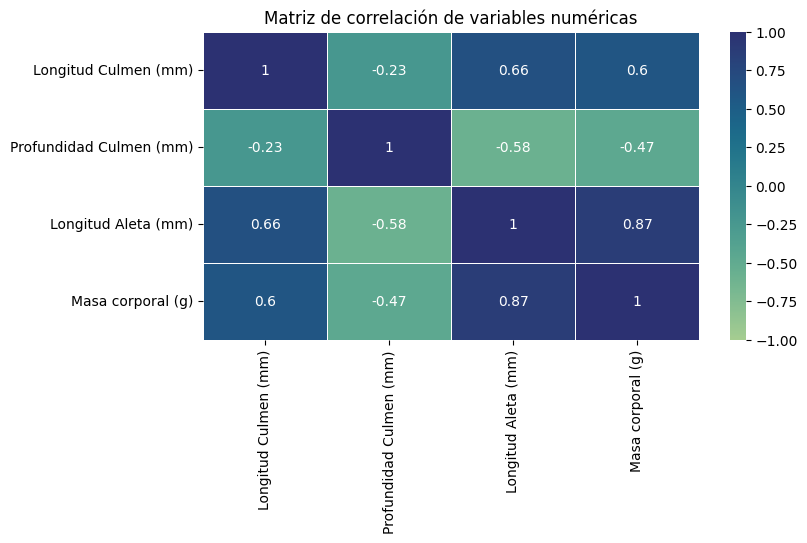

In [55]:
corr = pinguinos.select_dtypes(include='number').corr()
plt.figure(figsize=(8, 4))
sns.heatmap(
    corr,
    annot=True,
    cmap='crest',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title('Matriz de correlación de variables numéricas')
plt.show()

Interpretación:
- Se observa la relación positiva más fuerte entre Longitud de aleta y Masa Corporal = 0.87, lo que indica que a mayor tamaño de aleta, mayor es la masa corporal.
- Hay una relación positiva moderada entre Longitud del culmen y las variables de tamaño corporal, lo que sugiere que el tamaño del pico se asocia al tamaño general del pingüino.
- La Profundidad del culmen tiene correlación negativa con las variables de tamaño, indicando que los individuos más grandes tienden a tener picos menos profundos.

## Variables categóricas

In [56]:
categoricas = pinguinos.select_dtypes(include='object').columns
for col in categoricas:
    print(pinguinos[col].value_counts())
    print()

Especie
Adelie Penguin       154
Gentoo penguin       125
Chinstrap penguin     68
Name: count, dtype: int64

Sexo
MALE      170
FEMALE    166
.           1
Name: count, dtype: int64



Interpretación:
- La especie dominante es Adelie, seguida de Gentoo.
- Chinstrap es la especie minoritaria con la mitad o menos ejemplares que las otras dos.
- En cuento al Sexo, la distribución entre machos y hembras es equilibrada.
- Se observa un registro atípico "." que probabalemente corresponde a un error o faltante. Lo reemplazamos por NaN.

In [57]:
pinguinos['Sexo'] = pinguinos['Sexo'].replace(".", np.nan)

In [58]:
# filas duplicadas
pinguinos.duplicated().sum()

np.int64(3)

El dataset cuenta con 3 filas completas que están duplicadas, por lo cual, se eliminan.

In [59]:
pinguinos.drop_duplicates(inplace=True)
pinguinos.duplicated().sum()

np.int64(0)

Se decide simplificar el nombre, eliminando "penguin"/ "Penguin".

In [60]:
pinguinos['Especie'] = pinguinos['Especie'].str.replace(r'\s*[Pp]enguin', '', regex=True)

pinguinos['Especie'].value_counts()

,count
Especie,
Adelie,152
Gentoo,124
Chinstrap,68


## Distribución de variables categóricas

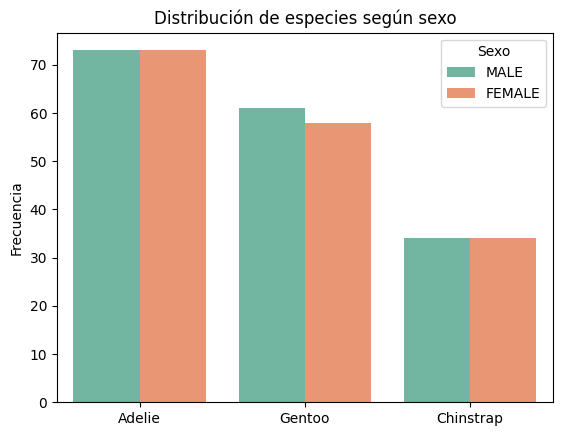

In [61]:
# Distribución de Especies por Sexo

sns.countplot(data=pinguinos, x='Especie', order=pinguinos['Especie'].value_counts().index, hue='Sexo', palette='Set2')
plt.title('Distribución de especies según sexo')
plt.xlabel('')
plt.ylabel('Frecuencia')
plt.show()

Interpretación:

La distribución entre machos y hembras es bastante equilibrada dentro de cada especie.

## Valores faltantes

In [62]:
# Cantidad y porcentaje de nulos por columna
nulos = pinguinos.isna().sum()
porcentaje_nulos = pinguinos.isna().mean().round(4) * 100
nulos_df = pd.DataFrame({'Cantidad': nulos, 'Porcentaje': porcentaje_nulos})
print(nulos_df)

                         Cantidad  Porcentaje
Especie                         0        0.00
Longitud Culmen (mm)            2        0.58
Profundidad Culmen (mm)         2        0.58
Longitud Aleta (mm)             2        0.58
Masa corporal (g)               2        0.58
Sexo                           11        3.20


## Filas con al menos un valor nulo

In [63]:
pinguinos[pinguinos.isnull().any(axis=1)]

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
3,Adelie,NaN,NaN,NaN,NaN,NaN
8,Adelie,34.1,18.1,193.0,3475.0,NaN
9,Adelie,42.0,20.2,190.0,4250.0,NaN
10,Adelie,37.8,17.1,186.0,3300.0,NaN
11,Adelie,37.8,17.3,180.0,3700.0,NaN
47,Adelie,37.5,18.9,179.0,2975.0,NaN
248,Gentoo,44.5,14.3,216.0,4100.0,NaN
289,Gentoo,46.2,14.4,214.0,4650.0,NaN
327,Gentoo,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,44.5,15.7,217.0,4875.0,NaN


Interpretación

- Las variables numéricas tienen apenas dos valores nulos cada una (menos del 1%) correspondientes a las filas 3 y 342, que están completamente vacías y no aportan información.
- La variable Sexo tiene 11 nulos (3,2%) que incluyen las dos filas anteriores más nueve filas donde solo falta ese dato.
- Como el total de filas con nulos representa menos del 3,5% del dataset, la decisión es eliminarlas, ya que no se compromete la calidad del análisis.

In [64]:
pinguinos = pinguinos.dropna().reset_index(drop=True)
print(f'Cantidad de filas después de eliminar nulos: {pinguinos.shape[0]}')

Cantidad de filas después de eliminar nulos: 333


El dataset pasó de 347 a 333 filas. Al ser una diferencia menor al 3,5% la distribución de datos no se ve afectada y el dataset sigue siendo representativo.

## Valores atípicos

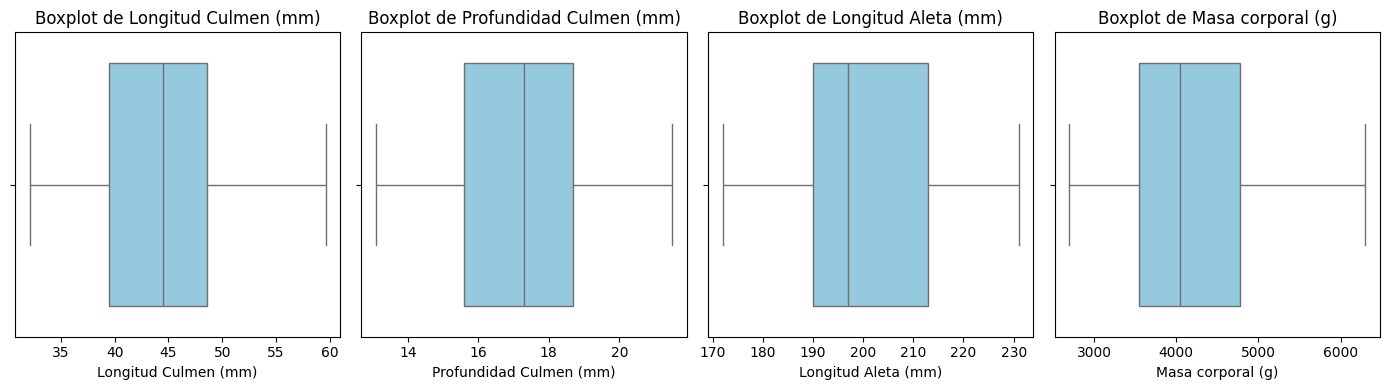

In [65]:
numericas = pinguinos.select_dtypes(include='number').columns
fig, axes = plt.subplots(nrows=1, ncols=len(numericas), figsize=(14, 4))
for i, col in enumerate(numericas):
    sns.boxplot(data=pinguinos, x=col, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()

In [66]:
numericas = pinguinos.select_dtypes(include='number').columns

for col in numericas:
    q1 = pinguinos[col].quantile(0.25)
    q3 = pinguinos[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = pinguinos[(pinguinos[col] < lower_bound) | (pinguinos[col] > upper_bound)]
    print(f"Atípicos en {col}: {len(outliers)} | {len(outliers)/len(pinguinos)*100:.2f}%")

Atípicos en Longitud Culmen (mm): 0 | 0.00%
Atípicos en Profundidad Culmen (mm): 0 | 0.00%
Atípicos en Longitud Aleta (mm): 0 | 0.00%
Atípicos en Masa corporal (g): 0 | 0.00%


Interpretación:

Los boxplots no muestran valores atípicos. Además lo confirmamos tomando el criterio IQR, por lo que no hay que hacer ningún tratamiento.

## Codificación de variables categóricas

La única variable categórica no target, Sexo, se codifica con One Hot Encoding. De manera que: Sexo_Male -> 1=True | 0=False

In [67]:
# Se verifica si la columna 'Sexo' existe antes de intentar codificarla.
if 'Sexo' in pinguinos.columns:
    pinguinos = pd.get_dummies(pinguinos, columns=['Sexo'], drop_first=True)
# Luego, se setea que la columna 'Sexo_Male' (el resultado esperado de la codificación) sea de tipo entero.
if 'Sexo_Male' in pinguinos.columns:
    pinguinos['Sexo_Male'] = pinguinos['Sexo_Male'].astype(int)
else:
    print("La columna 'Sexo_Male' no se encontró")

pinguinos.head()

La columna 'Sexo_Male' no se encontró


,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo_MALE
0,Adelie,39.1,18.7,181.0,3750.0,True
1,Adelie,39.5,17.4,186.0,3800.0,False
2,Adelie,40.3,18.0,195.0,3250.0,False
3,Adelie,36.7,19.3,193.0,3450.0,False
4,Adelie,39.3,20.6,190.0,3650.0,True


## Separación entre X e Y

- X: variables predictoras
- y: variable objetivo (Especie)

In [68]:
X = pinguinos.drop(columns=['Especie'])
y = pinguinos['Especie']

print("Variables predictoras")
display(X.head())
print("Variable target")
display(y.head())

Variables predictoras


,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo_MALE
0,39.1,18.7,181.0,3750.0,True
1,39.5,17.4,186.0,3800.0,False
2,40.3,18.0,195.0,3250.0,False
3,36.7,19.3,193.0,3450.0,False
4,39.3,20.6,190.0,3650.0,True


Variable target


,Especie
0,Adelie
1,Adelie
2,Adelie
3,Adelie
4,Adelie


## Normalización de variables numéricas

Se estandarizan usando StandardScaler, que deja cada variable con media = 0 y desvío estándar = 1.

In [69]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_scaled.head()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo_MALE
0,-0.896042,0.780732,-1.426752,-0.568475,0.991031
1,-0.822788,0.119584,-1.069474,-0.506286,-1.009050
2,-0.676280,0.424729,-0.426373,-1.190361,-1.009050
3,-1.335566,1.085877,-0.569284,-0.941606,-1.009050
4,-0.859415,1.747026,-0.783651,-0.692852,0.991031


# 2. PCA - Análisis de componentes principales

Se aplica PCA para reducir la dimensionalidad del dataset y analizar la estructura a través de sus componentes principales.

In [70]:
# PCA con todas las componentes posibles: min(n_muestras - 1, n_variables) = min(333, 5) = 5
pca_full = PCA()
pca_full.fit_transform(X_scaled)

# Autovalores y varianzas
autovalores = pca_full.explained_variance_
varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Tabla resumen
resumen_pca = pd.DataFrame({
    'Componente': [f'CP{i+1}' for i in range(len(autovalores))],
    'Autovalor (λ)': np.round(autovalores, 4),
    'Varianza explicada (%)': np.round(varianza_explicada * 100, 2),
    'Varianza acumulada (%)': np.round(varianza_acumulada * 100, 2)
})
display(resumen_pca)

,Componente,Autovalor (λ),Varianza explicada (%),Varianza acumulada (%)
0,CP1,2.8442,56.71,56.71
1,CP2,1.4114,28.14,84.86
2,CP3,0.4867,9.70,94.56
3,CP4,0.1728,3.45,98.01
4,CP5,0.0999,1.99,100.00


Interpretación:

CP1 y CP2 acumulan casi el 85% de la varianza, esto indica que pueden ser suficientes para representar la mayor parte de la información del dataset.

## Criterio 1: Varianza acumulada

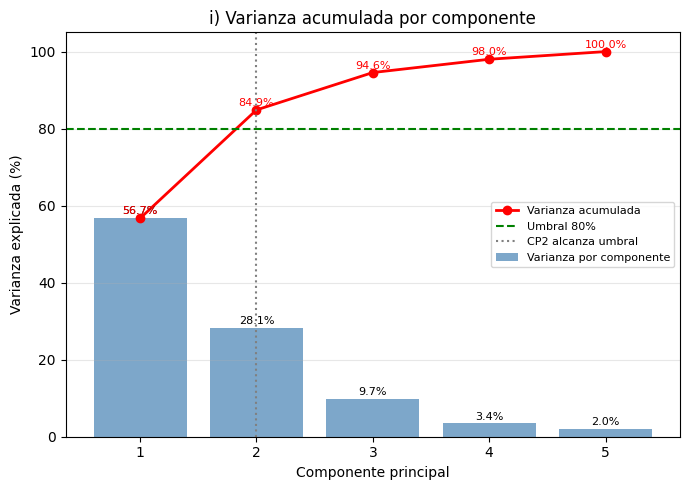

In [71]:
# Criterio 1: Varianza acumulada (~75% - 80%)
n_comp_varianza = int(np.argmax(varianza_acumulada >= 0.80)) + 1

fig, ax1 = plt.subplots(figsize=(7, 5))

bars = ax1.bar(range(1, len(varianza_explicada) + 1), varianza_explicada * 100,
               alpha=0.7, color='steelblue', label='Varianza por componente')
line_vals = varianza_acumulada * 100
ax1.plot(range(1, len(varianza_acumulada) + 1), line_vals,
         'o-', color='red', linewidth=2, markersize=6, label='Varianza acumulada')

for bar, v in zip(bars, varianza_explicada * 100):
    ax1.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%",
             ha='center', va='bottom', fontsize=8)

for i, v in enumerate(line_vals):
    ax1.text(i + 1, v + 0.5, f"{v:.1f}%", color='red',
             ha='center', va='bottom', fontsize=8)

ax1.axhline(y=80, color='green', linestyle='--', linewidth=1.5, label='Umbral 80%')
ax1.axvline(x=n_comp_varianza, color='gray', linestyle=':', linewidth=1.5,
            label=f'CP{n_comp_varianza} alcanza umbral')
ax1.set_xlabel('Componente principal')
ax1.set_ylabel('Varianza explicada (%)')
ax1.set_title('i) Varianza acumulada por componente')
ax1.set_xticks(range(1, len(varianza_explicada) + 1))
ax1.legend(fontsize=8)
ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Interpretación:

CP1 y CP2 superan el criterio (75% - 80%) acumulando casi el 85% de la varianza.

In [72]:
# Criterio 2: Kaiser (λ > 1)
n_comp_kaiser = int(np.sum(autovalores > 1))
print('Criterio de Kaiser (λ > 1):')
print(f"{'Componente':<12} {'Autovalor (λ)':<18} {'Decisión'}")
print('-' * 50)
for i, lam in enumerate(autovalores):
    decision = 'conservar' if lam > 1 else 'descartar'
    print(f'  CP{i+1:<9} {lam:<18.4f} {decision}')
print()
print(f'Kaiser sugiere {n_comp_kaiser} componentes')

Criterio de Kaiser (λ > 1):
Componente   Autovalor (λ)      Decisión
--------------------------------------------------
  CP1         2.8442             conservar
  CP2         1.4114             conservar
  CP3         0.4867             descartar
  CP4         0.1728             descartar
  CP5         0.0999             descartar

Kaiser sugiere 2 componentes


**Interpretación:**
CP1 (λ=2.84) y CP2 (λ=1.41) superan el umbral λ > 1. CP3 (λ=0.49) no. Se retienen **2 componentes**.

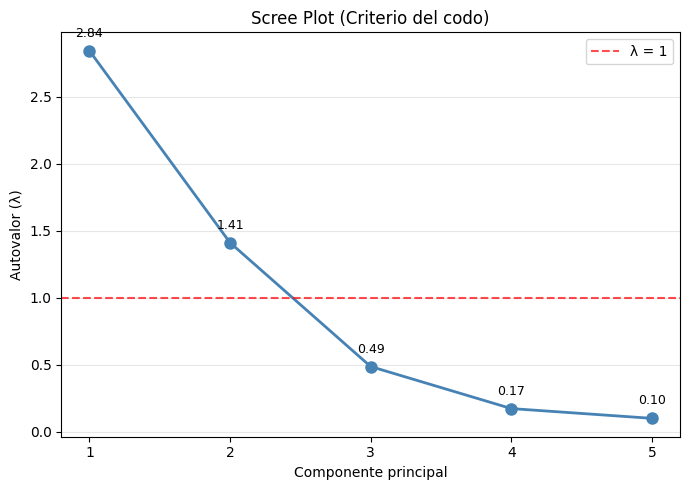

In [73]:
# Criterio 3: Scree Plot (criterio del codo)
fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.plot(range(1, len(autovalores) + 1), autovalores,
         'o-', color='steelblue', linewidth=2, markersize=8)
ax2.axhline(y=1, color='red', linestyle='--', alpha=0.7, label='λ = 1')
for i, lam in enumerate(autovalores):
    ax2.annotate(f'{lam:.2f}', xy=(i + 1, lam),
                 xytext=(0, 10), textcoords='offset points',
                 ha='center', fontsize=9)
ax2.set_xlabel('Componente principal')
ax2.set_ylabel('Autovalor (λ)')
ax2.set_title('Scree Plot (Criterio del codo)')
ax2.set_xticks(range(1, len(autovalores) + 1))
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretación:**
La caída más pronunciada ocurre entre CP2 y CP3 (de 1.41 a 0.49), marcando el codo en CP2. Se retienen **2 componentes**.

## Selección del criterio

Los tres criterios coinciden en retener **2 componentes principales**. Se selecciona el **criterio de varianza acumulada** como criterio principal, respaldado por Kaiser y el Scree Plot. Además, 2 componentes permiten visualización directa en 2D.

In [74]:
# Aplicamos PCA final con 2 componentes principales
n_final = 2
pca = PCA(n_components=n_final)
componentes = pca.fit_transform(X_scaled)

print(f"PCA aplicado con {n_final} componentes principales.")
print(f"  CP1: {pca.explained_variance_ratio_[0]*100:.2f}% de varianza explicada")
print(f"  CP2: {pca.explained_variance_ratio_[1]*100:.2f}% de varianza explicada")
print(f"  Total acumulado: {pca.explained_variance_ratio_.sum()*100:.2f}%")

PCA aplicado con 2 componentes principales.
  CP1: 56.71% de varianza explicada
  CP2: 28.14% de varianza explicada
  Total acumulado: 84.86%


## Visualización de componentes principales

In [75]:
df_pca = pd.DataFrame(componentes[:, :2], columns=['CP1', 'CP2'])
df_pca['Especie'] = pinguinos['Especie'].astype(str)

fig_pca_2d = px.scatter(
    df_pca,
    x='CP1',
    y='CP2',
    color='Especie',
    color_discrete_sequence=['#66c2a5', '#fc8d62', '#8da0cb'],
    category_orders={
        'Especie': ['Adelie', 'Chinstrap', 'Gentoo']
    },
    title='Componentes principales PCA - Especies de pingüinos',
    width=650,
    height=400
)

fig_pca_2d.show()

**Interpretación:**  

- La proyección 2D con PCA logra separar las tres especies, aunque con un solapamiento considerable entre Adelie y Chinstrap, consistente con lo observado en el EDA.

- Gentoo en cambio, forma un cluster bien diferenciado.

- PCA logra preservar la estructura suficiente para distinguir las tres especies, reduciendo el espacio de 5 variables originales a solo 2 componentes principales.

# 3. Isomap

Se aplica Isomap para reducir la dimensionalidad del dataset y analizar su estructura preservando las relaciones no lineales entre las observaciones.

#### Análisis de número de vecinos

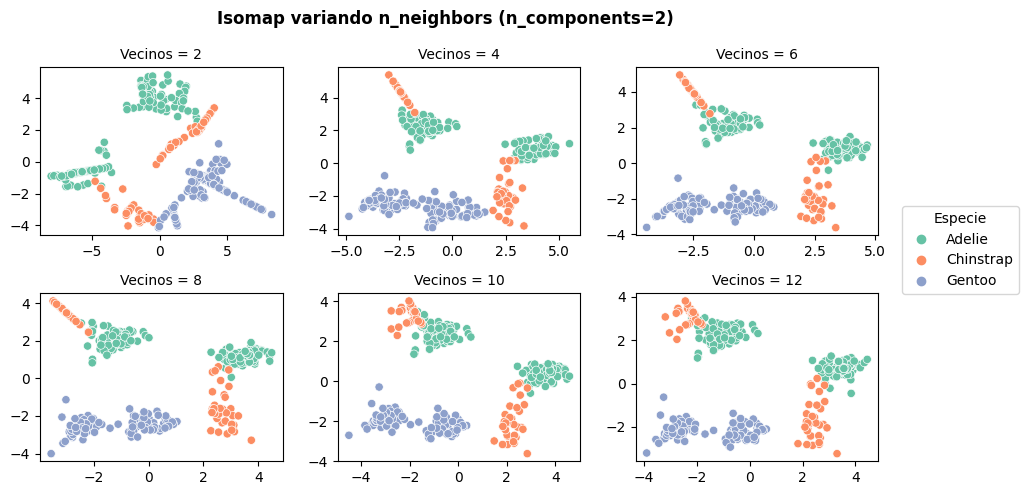

In [76]:
warnings.filterwarnings('ignore')
vecinos = [2, 4, 6, 8, 10, 12]
n_comp_fijo = 2

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes = axes.flatten()

for ax, n in zip(axes, vecinos):
    isomap = Isomap(n_neighbors=n, n_components=n_comp_fijo)
    X_iso = isomap.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_iso[:, 0],
        y=X_iso[:, 1],
        hue=y,
        palette='Set2',
        ax=ax,
        legend=False
    )

    ax.set_title(f'Vecinos = {n}', fontsize=10)
    # ax.set_xlabel('C1') # Para que no quede tan grande el subplot y se vean todos
    # ax.set_ylabel('C2')

plt.suptitle('Isomap variando n_neighbors (n_components=2)', fontsize=12, fontweight='bold')
plt.tight_layout()

# Creación de leyenda
legend_elements = [
    Line2D([0], [0], marker='o', linestyle='', label='Adelie',color='#66c2a5'),
    Line2D([0], [0], marker='o', linestyle='', label='Chinstrap',color='#fc8d62'),
    Line2D([0], [0], marker='o', linestyle='', label='Gentoo',color='#8da0cb')
]

fig.legend(
    handles=legend_elements,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    ncol=1,
    frameon=True
)
plt.show()

**Interpretación:**
- Con 2 vecinos la proyección es inestable: los clusters aparecen fragmentados y dispersos, sin una separación clara entre especies.
- A partir de 6–8 vecinos los grupos se vuelven más compactos y la separación mejora notablemente. Esto coincide con lo visto en el EDA: Gentoo se distingue con facilidad gracias a sus aletas más largas y mayor masa corporal.
- Adelie y Chinstrap continúan solapándose en la proyección, lo cual también es consistente con el EDA donde se observó que ambas especies comparten características similares.
- Con 10–12 vecinos la proyección se estabiliza y los clusters dejan de cambiar significativamente, lo que indica que el modelo ya no es sensible al parámetro en ese rango. El punto óptimo para este dataset parece estar entre 6 y 10.

**Conclusión:**  

Se decide utilizar **n_neighbors = 8**, ya que es el valor donde se observa una proyección más estable y una mejor separación visual entre clusters, particularmente entre Chinstrap y Adelie (las dos especies más similares), sin que colapsen entre sí como ocurre con valores mayores.

#### Análisis de número de componentes

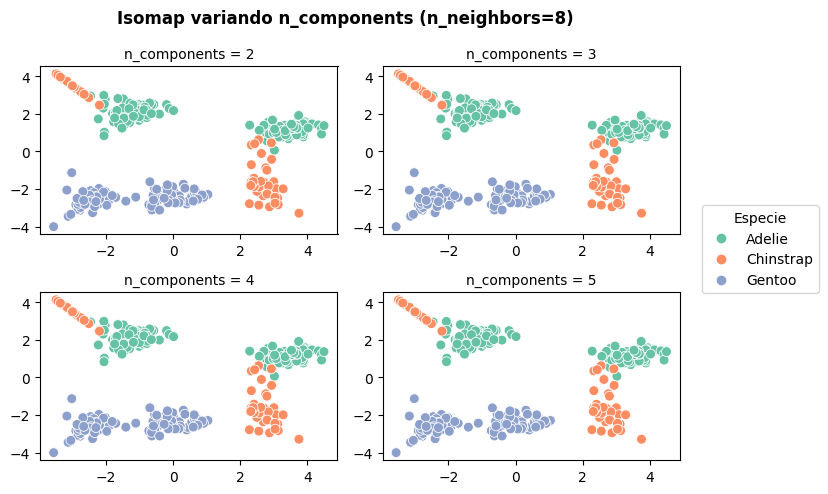

In [77]:
componentes = [2, 3, 4, 5]
n_vecinos_fijo = 8

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for ax, comp in zip(axes, componentes):
    isomap = Isomap(n_neighbors=n_vecinos_fijo, n_components=comp)
    X_iso = isomap.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_iso[:, 0],
        y=X_iso[:, 1],
        hue=y,
        palette='Set2',
        ax=ax,
        legend=False,
        s=50
    )

    ax.set_title(f'n_components = {comp}', fontsize=10)
    # ax.set_xlabel('C1') # Para que no quede tan grande el subplot y se vean todos
    # ax.set_ylabel('C2')

plt.suptitle('Isomap variando n_components (n_neighbors=8)', fontsize=12, fontweight='bold')


legend_elements = [
    Line2D([0], [0], marker='o', linestyle='', label='Adelie', color='#66c2a5'),
    Line2D([0], [0], marker='o', linestyle='', label='Chinstrap', color='#fc8d62'),
    Line2D([0], [0], marker='o', linestyle='', label='Gentoo', color='#8da0cb')
]

fig.legend(
    handles=legend_elements,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

**Interpretación:**

La proyección en 2D se mantiene muy similar en todos los gráficos al variar n_components entre 2 y 5, lo que sugiere que las dos primeras componentes preservan la mayor parte de la estructura geométrica relevante del dataset.

Agregar más componentes no aporta información nueva a la vista en 2D, ya que la distribución de las especies se mantiene prácticamente igual.


**Conclusión:**  

Se concluye que **n_components = 2** es suficiente para representar la separación entre especies en este dataset, ya que agregar más componentes no genera cambios visibles en la proyección ni aporta información adicional relevante en la visualización 2D.

### Aplicación de Isomap con parámetros seleccionados

In [78]:
isomap = Isomap(n_neighbors = 8,
                n_components = 3) # Aqui solo usamos 3 para poder graficar en 3D
X_reduced = isomap.fit_transform(X_scaled)

df_isomap = pd.DataFrame(X_reduced, columns=['PC1', 'PC2', 'PC3'])
df_isomap['Especie'] = y
df_isomap.head()

,PC1,PC2,PC3,Especie
0,-0.955501,2.451119,1.188091,Adelie
1,2.827308,1.550712,0.132943,Adelie
2,2.797344,0.551062,0.194947,Adelie
3,3.875065,0.769203,0.466182,Adelie
4,-1.481478,2.791781,0.770074,Adelie


In [79]:
fig_isomap_2d = px.scatter(
    df_isomap,
    x='PC1',
    y='PC2',
    color='Especie',
    color_discrete_sequence=['#66c2a5', '#fc8d62', '#8da0cb'],
    category_orders={'Especie': ['Adelie', 'Chinstrap', 'Gentoo']},
    title='Isomap 2D con n_neighbors = 8 y n_components = 2',
    width=650,
    height=400
)

fig_isomap_2d.show()

**Interpretación:**
- Con **n_neighbors = 8** y **n_components = 2**, la proyección 2D logra separar las tres especies de forma clara.

- La separación entre Gentoo y las otras dos especies es la más nítida, mientras que Adelie y Chinstrap muestran algo de solapamiento, **aunque menor que el observado con PCA**, lo que es consistente con su similitud morfológica y con lo observado durante el EDA.

- Los parámetros seleccionados resultan adecuados para representar la estructura del dataset en 2D, lo que respalda la elección realizada en el análisis previo.

# 4. t-SNE

Se aplica t-SNE para reducir la dimensionalidad del dataset y visualizar su estructura preservando relaciones locales entre las observaciones.

### Análisis de perplejidad

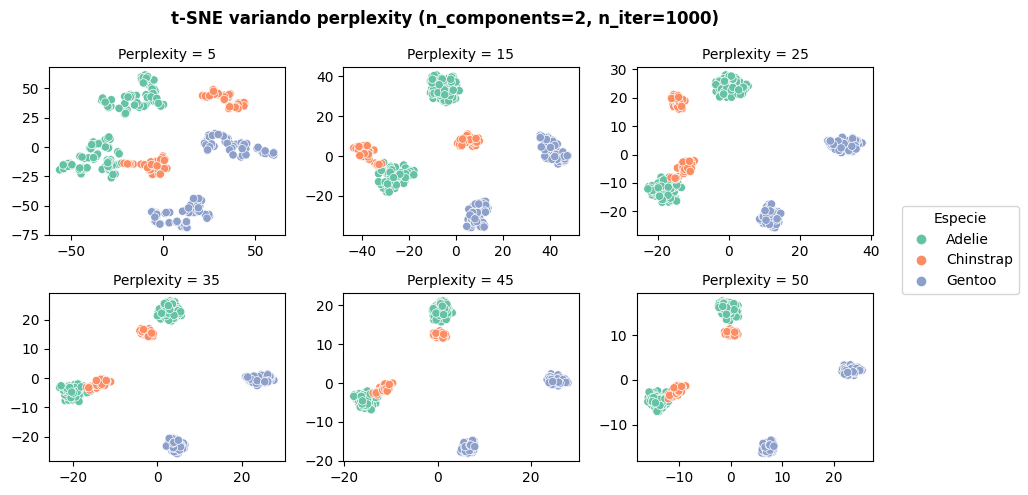

In [80]:
perplexidades = [5, 15, 25, 35, 45, 50]
n_comp_fijo = 2
n_iter_fijo = 1000

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes = axes.flatten()

for ax, perp in zip(axes, perplexidades):
    tsne = TSNE(n_components=n_comp_fijo, perplexity=perp, max_iter=n_iter_fijo, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        hue=y,
        palette='Set2',
        ax=ax,
        legend=False
    )
    ax.set_title(f'Perplexity = {perp}', fontsize=10)

plt.suptitle('t-SNE variando perplexity (n_components=2, n_iter=1000)', fontsize=12, fontweight='bold')
plt.tight_layout()

legend_elements = [
    Line2D([0], [0], marker='o', linestyle='', label='Adelie', color='#66c2a5'),
    Line2D([0], [0], marker='o', linestyle='', label='Chinstrap', color='#fc8d62'),
    Line2D([0], [0], marker='o', linestyle='', label='Gentoo', color='#8da0cb')
]
fig.legend(handles=legend_elements, title='Especie', loc='center left',
           bbox_to_anchor=(1, 0.5), ncol=1, frameon=True)
plt.show()

**Interpretación:**
- Con perplexity = 5 los clusters aparecen fragmentados y dispersos, sin una separación clara entre especies.
- A partir de perplexity = 15 las tres especies comienzan a formar grupos más compactos y diferenciados. Gentoo se separa con claridad, consistente con lo observado en el EDA, mientras que Adelie y Chinstrap muestran cierto solapamiento entre sí.
- Con perplexity = 35 en adelante la separación se mantiene estable y los clusters están bien definidos, sin mejoras significativas al seguir aumentando el valor, aunque se observa un leve incremento en el solapamiento entre especies a medida que la perplexity crece.

**Conclusión:**  

Se elige **perplexity = 25**, donde la separación entre especies es clara y los clusters ya se muestran compactos y bien definidos, sin necesidad de aumentar el valor.

### Análisis de número de iteraciones

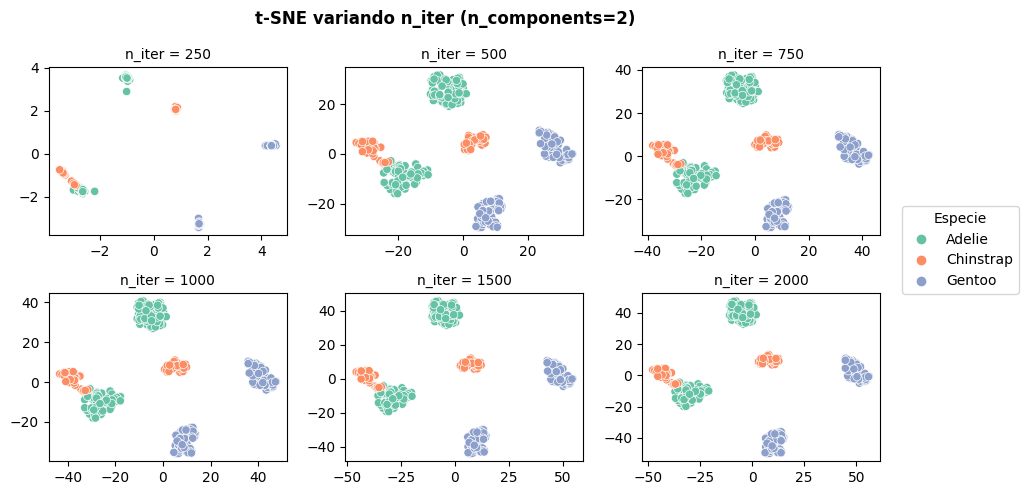

In [81]:
iteraciones = [250, 500, 750, 1000, 1500, 2000]
n_comp_fijo = 2
perp_fijo = 15

fig, axes = plt.subplots(2, 3, figsize=(9, 5))
axes = axes.flatten()

for ax, n_iter in zip(axes, iteraciones):
    tsne = TSNE(n_components=n_comp_fijo, perplexity=perp_fijo, max_iter=n_iter, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        hue=y,
        palette='Set2',
        ax=ax,
        legend=False
    )
    ax.set_title(f'n_iter = {n_iter}', fontsize=10)

plt.suptitle('t-SNE variando n_iter (n_components=2)', fontsize=12, fontweight='bold')
plt.tight_layout()

fig.legend(handles=legend_elements, title='Especie', loc='center left',
           bbox_to_anchor=(1, 0.5), ncol=1, frameon=True)
plt.show()

**Interpretación:**
- Con 250 iteraciones la proyección no converge: los clusters aparecen dispersos y sin estructura clara.
- A partir de 500–750 iteraciones los tres grupos se forman con buena separación y compacidad.
- Con 1000 o más iteraciones la proyección se estabiliza y no muestra cambios significativos respecto a 500.

**Conclusión:**  

Se elige **n_iter = 500**, ya que la proyección ya converge con claridad y valores mayores no aportan mejoras que justifiquen el costo computacional extra.

### Análisis de número de componentes

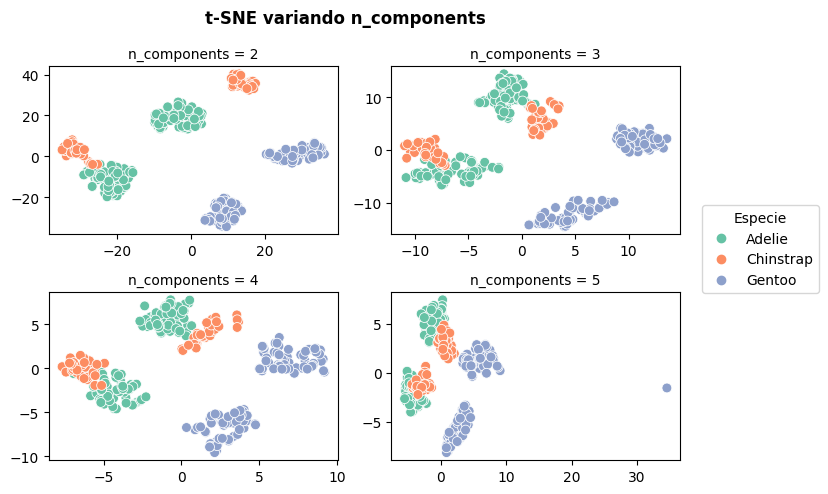

In [82]:
componentes = [2, 3, 4, 5]
perp_fijo = 15
n_iter_fijo = 500

fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

for ax, comp in zip(axes, componentes):
    tsne = TSNE(
        n_components=comp,
        perplexity=perp_fijo,
        max_iter=n_iter_fijo,
        random_state=42,
        method="exact" # Método más costoso computacionalmente que el default pero permite hasta 5 componentes
    )

    X_tsne = tsne.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_tsne[:, 0],
        y=X_tsne[:, 1],
        hue=y,
        palette='Set2',
        ax=ax,
        legend=False,
        s=50
    )

    ax.set_title(f'n_components = {comp}', fontsize=10)
    # ax.set_xlabel('C1') # Para que no quede tan grande el subplot y se vean todos
    # ax.set_ylabel('C2')

plt.suptitle('t-SNE variando n_components', fontsize=12, fontweight='bold')

fig.legend(
    handles=legend_elements,
    title='Especie',
    loc='center left',
    bbox_to_anchor=(1, 0.5),
    frameon=True
)

plt.tight_layout()
plt.show()

**Interpretación:**
- Con n_components = 2 las tres especies se separan con claridad y los clusters se muestran compactos y bien diferenciados.
- Al aumentar a 3 y 4 componentes la separación se mantiene, pero Adelie y Chinstrap comienzan a solaparse más, perdiendo algo de la claridad que se tenía en 2D.
- Con n_components = 5 la proyección 2D se degrada notablemente: los clusters se comprimen, aparecen puntos aislados y la separación entre especies se vuelve menos clara.

**Conclusión:**   

Se elige **n_components = 2**, ya que es el valor que produce la proyección más clara y compacta, y aumentar las dimensiones no mejora la separación sino que la perjudica.

### Valores seleccionados

Se seleccionaron los siguientes valores a partir del análisis visual de las proyecciones:

- **perplexity = 25**: produce clusters compactos y bien separados entre especies.
- **n_iter = 500**: la proyección converge con claridad sin costo computacional innecesario.
- **n_components = 2**: es suficiente para representar la separación entre especies, valores mayores no aportan mejoras.

### Aplicación de t-SNE con parámetros seleccionados

In [83]:
tsne = TSNE(
    n_components=2,
    perplexity=15,
    max_iter=500,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

df_tsne = pd.DataFrame(X_tsne, columns=['C1', 'C2'])
df_tsne['Especie'] = y.values.astype(str)

fig_tsne_2d = px.scatter(
    df_tsne,
    x='C1',
    y='C2',
    color='Especie',
    color_discrete_sequence=['#66c2a5', '#fc8d62', '#8da0cb'],
    category_orders={
        'Especie': ['Adelie', 'Chinstrap', 'Gentoo']
    },
    title='t-SNE 2D con perplexity = 15 y max_iter = 500',
    width=650,
    height=400
)

fig_tsne_2d.show()

**Interpretación:**  

- Con **perplexity = 15** y **max_iter = 500**, la proyección 2D logra separar las tres especies de forma clara, formando clusters compactos y bien diferenciados.

- La separación entre Gentoo y las otras dos especies es la más nítida, mientras que Adelie y Chinstrap muestran un leve solapamiento, **mejorando la separación obtenida con PCA e Isomap**, lo que es consistente con su similitud morfológica y con lo observado durante el EDA.

- Los parámetros seleccionados resultan adecuados para representar la estructura del dataset en 2D, lo que respalda la elección realizada en el análisis previo.

# 5. K-means

Se aplica K-means para agrupar las observaciones del dataset en clusters según su similitud.

### Eliminación de la variable Sexo

Antes de aplicar **K-means**, se decidió trabajar con una versión del conjunto de datos **sin la variable Sexo**. La razón principal es que esta variable generaba subgrupos internos dentro de cada especie, lo que llevaba a obtener una mayor cantidad de clusters óptimos y hacía más difícil interpretar los resultados en función de la variable objetivo, que en este trabajo es **Especie**.

Además, se realizaron pruebas incluyendo Sexo, pero los valores obtenidos mediante GAP Statistic y Silhouette Score resultaban más difíciles de interpretar y menos consistentes con la estructura general observada previamente en PCA, Isomap y t-SNE.

Por este motivo, para el análisis de K-means se optó por excluir esta variable y enfocarse en las características morfológicas de los pingüinos.

Esta decisión es consistente con la práctica habitual en clustering, donde las variables categóricas binarias suelen excluirse del conjunto de features o tratarse por separado, dado que **K-means se basa en distancias euclidianas** y no está diseñado para manejar variables categóricas de forma nativa sin una codificación que pueda distorsionar el espacio métrico.

Esta decisión se mantendrá en todos los métodos de clustering aplicados.

In [84]:
X_cluster = X_scaled.drop(columns=['Sexo_MALE'])
X_cluster.head()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


### Análisis de número de clusters

#### Curva de Codo

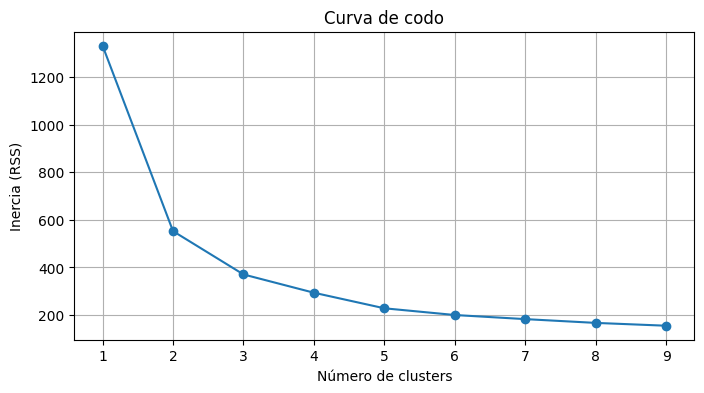

In [85]:
Nc = range(1, 10)
kmeans_list = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster) for k in Nc]
inertias = [model.inertia_ for model in kmeans_list]

plt.figure(figsize=(8, 4))
# Convertimos 'inertias' a un array de NumPy para evitar la advertencia de tipo
plt.plot(Nc, np.array(inertias), 'o-')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia (RSS)')
plt.title('Curva de codo')
plt.grid()
plt.show()

**Interpretación:**  

- La curva disminuye con fuerza hasta **k = 3** y luego comienza a aplanarse.

- Esto indica que el codo se encuentra en **k = 3**, ya que agregar más clusters no mejora significativamente el ajuste del modelo.

#### GAP Statistic

Número óptimo de clusters según GAP: 6


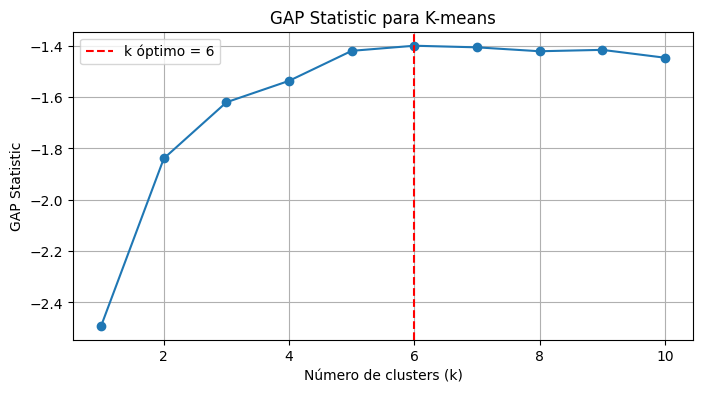

In [86]:
def calculate_intra_cluster_dispersion(X, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    return kmeans.inertia_

np.random.seed(42)
gaps = []
max_k = 10

for k in range(1, max_k + 1):
    real_inertia = calculate_intra_cluster_dispersion(X_cluster, k)
    inertia_list = []
    for _ in range(20):
        random_data = np.random.rand(*X_cluster.shape)
        inertia_list.append(calculate_intra_cluster_dispersion(random_data, k))
    reference_inertia = np.mean(inertia_list)
    gaps.append(np.log(reference_inertia) - np.log(real_inertia))

optimal_k_gap = np.argmax(gaps) + 1
print('Número óptimo de clusters según GAP:', optimal_k_gap)

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_k + 1), gaps, marker='o')
plt.axvline(x=optimal_k_gap, color='red', linestyle='--', label=f'k óptimo = {optimal_k_gap}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('GAP Statistic')
plt.title('GAP Statistic para K-means')
plt.legend()
plt.grid()
plt.show()

**Interpretación:**  
- El GAP Statistic alcanza su valor máximo en **k = 6**, lo que sugiere la presencia de seis subgrupos bien definidos en los datos.

- Este resultado puede interpretarse como la formación de dos subgrupos dentro de cada una de las tres especies. Aunque la variable sexo fue removida, otras variables morfológicas todavía conservan diferencias entre machos y hembras, por lo que esa estructura sigue apareciendo en los datos.

- Esta interpretación también resulta coherente con lo observado en PCA, Isomap y t-SNE, donde se evidenciaban visualmente seis agrupamientos similares.

#### Score de Silhouette

Número óptimo de clusters según Silhouette: 2


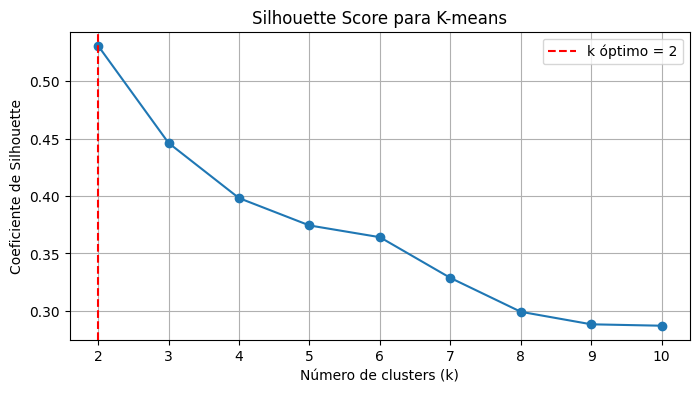

In [87]:
silhouette_scores = []

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    silhouette_scores.append(silhouette_score(X_cluster, labels))

optimal_k_sil = np.argmax(silhouette_scores) + 2
print('Número óptimo de clusters según Silhouette:', optimal_k_sil)

plt.figure(figsize=(8, 4))
plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
plt.axvline(x=optimal_k_sil, color='red', linestyle='--', label=f'k óptimo = {optimal_k_sil}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Silhouette Score para K-means')
plt.legend()
plt.grid()
plt.show()

**Interpretación:**

- El coeficiente de Silhouette alcanza su valor máximo en **k = 2**, lo que indica que la mejor separación global de los datos se da en dos grandes grupos.

- Este resultado puede interpretarse como una división más general entre la especie Gentoo y el conjunto formado por Adelie y Chinstrap. Esta separación ya se observaba en el EDA, donde Gentoo presentaba diferencias morfológicas más marcadas, especialmente en masa corporal y longitud de aleta, mientras que las otras dos especies mostraban valores más cercanos entre sí.

- Esta lectura también es consistente con lo observado previamente en PCA, Isomap y t-SNE, donde Gentoo tendía a separarse claramente del resto, mientras que Adelie y Chinstrap mostraban mayor solapamiento entre sí.

#### Selección final de k

A partir de los criterios analizados, se obtuvieron distintos valores candidatos para el número óptimo de clusters:

- **Curva de codo:** k = 3
- **GAP Statistic:** k = 6
- **Silhouette Score:** k = 2

Cada métrica resalta una estructura diferente de los datos. Mientras que **Silhouette** prioriza una separación global en dos grandes grupos y **GAP** detecta subestructuras más finas, la **curva de codo** sugiere una partición intermedia en tres clusters.

Dado que el objetivo principal del trabajo es analizar la agrupación en función de la variable **Especie**, compuesta por **tres clases reales**, se decide utilizar **k = 3** como valor final para aplicar K-means.

Esta elección permite obtener clusters más alineados con el problema planteado y resulta consistente con la estructura observada previamente en el EDA, PCA, Isomap y t-SNE.

### Aplicación de K-means con k óptimo

In [88]:
kmeans = KMeans(n_clusters=3, random_state=42, init='k-means++', n_init=10)
kmeans.fit(X_cluster)

X_std_plot = X_cluster.copy()
X_std_plot['Cluster'] = kmeans.labels_.astype(str)

fig = px.scatter_3d(
    X_std_plot,
    x='Longitud Aleta (mm)',
    y='Masa corporal (g)',
    z='Longitud Culmen (mm)',
    color='Cluster',
    color_discrete_sequence=['#66c2a5', '#fc8d62', '#8da0cb'],
    title='Clusters obtenidos con K-means (k = 3)')

fig.update_layout(
    height=600,
    scene=dict(
    camera=dict(
        eye=dict(x=1, y=-1, z=0))))

fig.show()

### Comparación con especies reales

In [89]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

# -------------------------
# DATOS
# -------------------------
labels = kmeans.labels_
species = pinguinos['Especie'].values
species_codes = pd.factorize(species)[0]

# -------------------------
# ALINEACIÓN HÚNGARA
# -------------------------
cm = confusion_matrix(species_codes, labels)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(col_ind, row_ind)}
labels_aligned = np.vectorize(mapping.get)(labels)

# -------------------------
# COLORES FIJOS
# -------------------------
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
species_names = pd.factorize(species)[1]

# -------------------------
# FIGURA
# -------------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("K-means alineado", "Especies reales")
)

# -------------------------
# KMEANS (SIN LEYENDA)
# -------------------------
for i in range(3):
    mask = labels_aligned == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            name=f'Cluster {i}',
            marker=dict(color=colors[i], size=4),
            showlegend=False
        ),
        row=1, col=1
    )

# -------------------------
# ESPECIES (CON LEYENDA)
# -------------------------
for i, name in enumerate(species_names):
    mask = species_codes == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            name=name,
            marker=dict(color=colors[i], size=4)
        ),
        row=1, col=2
    )

# -------------------------
# LAYOUT + CÁMARA
# -------------------------
fig.update_layout(
    title="K-means vs Especies",
    height=600,
scene=dict(
    xaxis_title="Longitud Aleta (mm)",
    yaxis_title="Masa corporal (g)",
    zaxis_title="Longitud Culmen (mm)",
    camera=dict(
        eye=dict(x=1, y=-1, z=0)
    )
),
scene2=dict(
    xaxis_title="Longitud Aleta (mm)",
    yaxis_title="Masa corporal (g)",
    zaxis_title="Longitud Culmen (mm)",
    camera=dict(
        eye=dict(x=1, y=-1, z=0)
    )
)
)

fig.show()

**Interpretación:**

- K-means logra una buena separación general de las tres especies, respetando bastante bien la estructura de los datos en el espacio reducido.

- El cluster Gentoo (azul) es el mejor identificado: aparece compacto, bien delimitado y prácticamente sin confusiones. Este resultado es consistente con lo observado en el EDA y en las reducciones de dimensionalidad, donde Gentoo siempre se separó con claridad del resto.

- Adelie (verde) también queda razonablemente bien definida, aunque en la zona de frontera con Chinstrap (naranja) se observan algunos errores de clasificación: ciertos pingüinos Adelie son asignados como Chinstrap en la región de solapamiento.

- Esta confusión entre Adelie y Chinstrap es esperable, ya que en el EDA ambas especies mostraron características morfológicas similares. Este solapamiento se mantiene incluso tras la reducción de dimensionalidad, como ya se había observado previamente.

# 6. Clustering Jerárquico  

Se aplica clustering jerárquico para agrupar las observaciones y analizar sus relaciones mediante una estructura en forma de dendrograma.

### Análisis Dendrograma

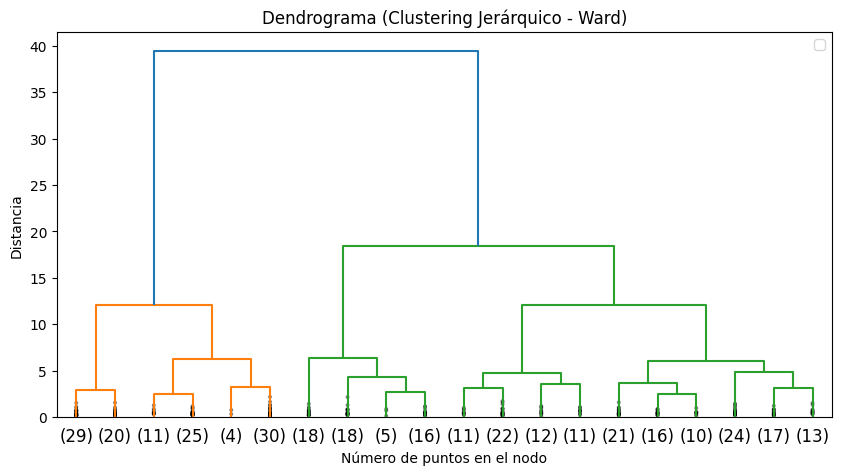

In [90]:
Z = linkage(X_cluster, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z, truncate_mode='lastp', p=20, show_leaf_counts=True, show_contracted=True)
# plt.axhline(y=15, color='red', linestyle='--', label='Corte sugerido')
plt.xlabel('Número de puntos en el nodo')
plt.ylabel('Distancia')
plt.title('Dendrograma (Clustering Jerárquico - Ward)')
plt.legend()
plt.show()

**Interpretación:**

- Un corte alrededor de distancia ≈ 15 permite obtener 3 clusters, lo que sugiere que **k = 3** es una elección razonable.

- El grupo naranja (izquierda) forma un cluster compacto y claramente separado del resto, consistente con la especie **Gentoo**.

- Los dos grupos restantes se fusionan recién a distancias cercanas a 18–19, lo que indica mayor similitud entre ellos, coherente con las especies **Adelie y Chinstrap**.

### Análisis de número óptimo de clusters

#### GAP Statistic

Número óptimo de clusters según GAP: 2


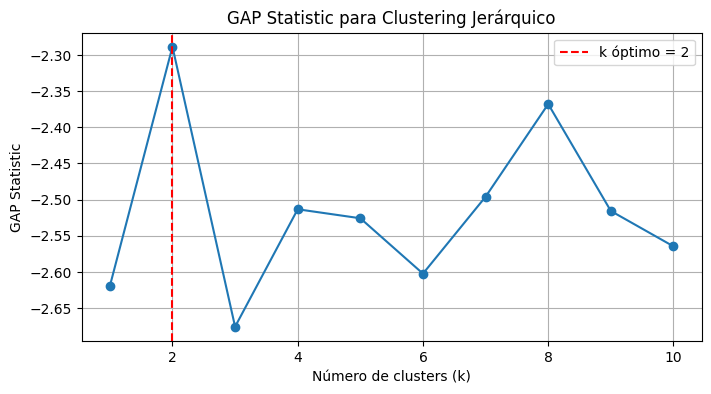

In [91]:
def calc_dispersion_hc(X, k):
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = clustering.fit_predict(X)
    X_np = X.to_numpy() if isinstance(X, pd.DataFrame) else X
    centroids = np.array([np.mean(X_np[labels == i], axis=0) for i in range(k)])
    return np.sum(np.linalg.norm(X_np[labels] - centroids[labels], axis=1) ** 2)

np.random.seed(42) # para tener resultados consistentes entre ejecuciones
gaps_hc = []
max_k = 10

for k in range(1, max_k + 1):
    real_inertia = calc_dispersion_hc(X_cluster, k)
    inertia_list = []
    for _ in range(20):
        random_data = np.random.rand(*X_cluster.shape)
        inertia_list.append(calc_dispersion_hc(random_data, k))
    reference_inertia = np.mean(inertia_list)
    gaps_hc.append(np.log(reference_inertia) - np.log(real_inertia))

optimal_k_gap_hc = np.argmax(gaps_hc) + 1
print('Número óptimo de clusters según GAP:', optimal_k_gap_hc)

plt.figure(figsize=(8, 4))
plt.plot(range(1, max_k + 1), gaps_hc, marker='o')
plt.axvline(x=optimal_k_gap_hc, color='red', linestyle='--', label=f'k óptimo = {optimal_k_gap_hc}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('GAP Statistic')
plt.title('GAP Statistic para Clustering Jerárquico')
plt.legend()
plt.grid()
plt.show()

**Interpretación:**

- El GAP Statistic alcanza su valor máximo en **k = 2**, sugiriendo que esa es la mejor partición.

- Este resultado difiere con el dendrograma y con la estructura real del dataset: las 3 especies de pingüinos.

#### Score de Silhouette

Número óptimo de clusters según Silhouette: 2


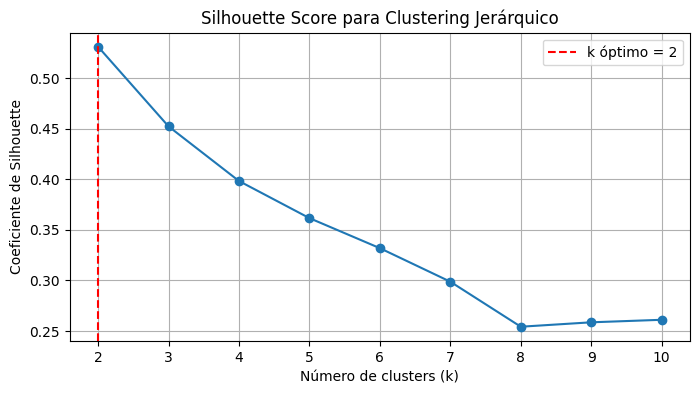

In [92]:
silhouette_scores_hc = []

for k in range(2, max_k + 1):
    clustering = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = clustering.fit_predict(X_cluster)
    silhouette_scores_hc.append(silhouette_score(X_cluster, labels))

optimal_k_sil_hc = np.argmax(silhouette_scores_hc) + 2
print('Número óptimo de clusters según Silhouette:', optimal_k_sil_hc)

plt.figure(figsize=(8, 4))
plt.plot(range(2, max_k + 1), silhouette_scores_hc, marker='o')
plt.axvline(x=optimal_k_sil_hc, color='red', linestyle='--', label=f'k óptimo = {optimal_k_sil_hc}')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de Silhouette')
plt.title('Silhouette Score para Clustering Jerárquico')
plt.legend()
plt.grid()
plt.show()

**Interpretación:**

- El coeficiente de Silhouette alcanza su valor máximo en **k = 2**, lo que indica que la mejor separación global de los datos se da en dos grandes grupos.

- Este resultado puede interpretarse como una división más general entre la especie Gentoo y el conjunto formado por Adelie y Chinstrap. Esta separación ya se observaba en el EDA, donde Gentoo presentaba diferencias morfológicas más marcadas, especialmente en masa corporal y longitud de aleta, mientras que las otras dos especies mostraban valores más cercanos entre sí. Al igual que en K-means, donde se observó un comportamiento similar para k = 2.

- Esta lectura también es consistente con lo observado previamente en PCA, Isomap y t-SNE, donde Gentoo tendía a separarse claramente del resto, mientras que Adelie y Chinstrap mostraban mayor solapamiento entre sí. De forma consistente con lo observado en K-means, donde estas dos especies también tendían a agruparse juntas.

#### Selección final de k

A partir de los criterios analizados, se obtuvieron distintos valores candidatos para el número óptimo de clusters:

- **Dendrograma (corte visual):** k = 3
- **GAP Statistic:** k = 2
- **Silhouette Score:** k = 2

En este caso, el **dendrograma** señala **k = 3** como la partición más adecuada. La **GAP Statistic** y el **Silhouette Score** sugieren k = 2, lo que refleja la mayor diferenciación entre Gentoo y el par Adelie–Chinstrap, pero no permite distinguir entre estas dos últimas especies.

Dado que el objetivo del trabajo es analizar la agrupación en función de la variable **Especie** —compuesta por tres clases reales—, **se decide utilizar k = 3** como valor final para aplicar el clustering jerárquico. Esta elección es consistente con la estructura observada en el EDA, PCA, Isomap, t-SNE y los resultados obtenidos con K-means.

### Aplicación de Clustering Jerárquico con k óptimo

In [96]:
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_cluster)

X_cluster_hc = X_cluster.copy()
X_cluster_hc['Cluster'] = labels_hc.astype(str)

print(f'Silhouette Score (k=3): {silhouette_score(X_cluster, labels_hc):.4f}')

Silhouette Score (k=3): 0.4521


**Interpretación:**

El Silhouette Score para **k = 3** es **0.4521**, lo que indica una **separación aceptable** entre los clusters. Esto sugiere que, si bien las tres especies presentan estructuras distinguibles, existe cierto solapamiento entre algunos grupos, lo cual es consistente con lo observado en el análisis exploratorio de datos (EDA).

In [98]:
# Visualización 3D

fig = px.scatter_3d(
    X_cluster_hc,
    x='Longitud Aleta (mm)',
    y='Masa corporal (g)',
    z='Longitud Culmen (mm)',
    color='Cluster',
    color_discrete_sequence=['#66c2a5', '#fc8d62', '#8da0cb'],
    title='Clusters obtenidos con Clustering Jerárquico (k = 3)')

fig.update_layout(
    height=600,
    scene=dict(
    camera=dict(
        eye=dict(x=1, y=-1, z=0))))

fig.show()

### Comparación con especies reales

In [100]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering

# -------------------------
# MODELO (HIERARCHICAL)
# -------------------------
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_cluster)

# -------------------------
# DATOS ESPECIES
# -------------------------
species = pinguinos['Especie'].values
species_codes = pd.factorize(species)[0]
species_names = pd.factorize(species)[1]

# -------------------------
# ALINEACIÓN HÚNGARA
# -------------------------
cm = confusion_matrix(species_codes, labels_hc)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(col_ind, row_ind)}
labels_aligned = np.vectorize(mapping.get)(labels_hc)

# -------------------------
# COLORES FIJOS
# -------------------------
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

# -------------------------
# FIGURA
# -------------------------
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("Aglomerativo (Ward)", "Especies reales")
)

# -------------------------
# CLUSTERS HIERARCHICAL
# -------------------------
for i in range(3):
    mask = labels_aligned == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            name=f'Cluster {i}',
            marker=dict(color=colors[i], size=4),
            showlegend=False
        ),
        row=1, col=1
    )

# -------------------------
# ESPECIES REALES
# -------------------------
for i, name in enumerate(species_names):
    mask = species_codes == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            name=name,
            marker=dict(color=colors[i], size=4)
        ),
        row=1, col=2
    )

# -------------------------
# LAYOUT
# -------------------------
fig.update_layout(
    title="Clustering Aglomerativo vs Especies",
    height=600,
    scene=dict(
        xaxis_title="Longitud Aleta (mm)",
        yaxis_title="Masa corporal (g)",
        zaxis_title="Longitud Culmen (mm)",
        camera=dict(eye=dict(x=1, y=-1, z=0))
    ),
    scene2=dict(
        xaxis_title="Longitud Aleta (mm)",
        yaxis_title="Masa corporal (g)",
        zaxis_title="Longitud Culmen (mm)",
        camera=dict(eye=dict(x=1, y=-1, z=0))
    )
)

fig.show()

**Interpretación:**

- El clustering aglomerativo con enlace Ward logra una separación muy precisa de las tres especies, con una calidad de clusters visualmente superior a la obtenida con K-means.

- El cluster Gentoo (azul) se mantiene perfectamente delimitado, sin confusiones, coherente con los análisis previos donde esta especie siempre mostró una separación clara.

- Adelie (verde) y Chinstrap (naranja) también presentan una mejor definición respecto a K-means: la zona de frontera entre ambas especies muestra menos puntos mal asignados, con confusiones solo en casos aislados.

- La confusión residual entre Adelie y Chinstrap se mantiene como un patrón esperable, dado el solapamiento morfológico ya observado en el EDA y en los métodos de reducción de dimensionalidad.

### Comparación de métodos de reducción de dimensionalidad

In [101]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# -------------------------
# FIGURA 1x3
# -------------------------
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=("PCA", "Isomap", "t-SNE")
)

# -------------------------
# COLORES POR ESPECIE
# -------------------------
species = df_pca['Especie'].unique()
colors = px.colors.qualitative.Set2
color_map = {sp: colors[i] for i, sp in enumerate(species)}

# =====================================================
# PCA
# =====================================================
for sp in species:
    mask = df_pca['Especie'] == sp

    fig.add_trace(
        go.Scatter(
            x=df_pca.loc[mask, 'CP1'],
            y=df_pca.loc[mask, 'CP2'],
            mode='markers',
            name=sp,
            marker=dict(size=6, color=color_map[sp]),
            showlegend=True
        ),
        row=1, col=1
    )

# =====================================================
# ISOMAP
# =====================================================
for sp in species:
    mask = df_isomap['Especie'] == sp

    fig.add_trace(
        go.Scatter(
            x=df_isomap.loc[mask, 'PC1'],
            y=df_isomap.loc[mask, 'PC2'],
            mode='markers',
            marker=dict(size=6, color=color_map[sp]),
            showlegend=False
        ),
        row=1, col=2
    )

# =====================================================
# t-SNE
# =====================================================
for sp in species:
    mask = df_tsne['Especie'] == sp

    fig.add_trace(
        go.Scatter(
            x=df_tsne.loc[mask, 'C1'],
            y=df_tsne.loc[mask, 'C2'],
            mode='markers',
            marker=dict(size=6, color=color_map[sp]),
            showlegend=False
        ),
        row=1, col=3
    )

# -------------------------
# LAYOUT
# -------------------------
fig.update_layout(
    title="Comparación PCA vs Isomap vs t-SNE",
    height=450,
    legend_title="Especie"
)

fig.update_xaxes(title_text="Dim 1", row=1, col=1)
fig.update_yaxes(title_text="Dim 2", row=1, col=1)

fig.update_xaxes(title_text="Dim 1", row=1, col=2)
fig.update_yaxes(title_text="Dim 2", row=1, col=2)

fig.update_xaxes(title_text="Dim 1", row=1, col=3)
fig.update_yaxes(title_text="Dim 2", row=1, col=3)

fig.show()

**Interpretación:**

- **PCA** logra separar Gentoo del resto, pero Adelie y Chinstrap presentan un solapamiento considerable, ya que al ser un método lineal no captura bien las diferencias entre especies morfológicamente similares.

- **Isomap** mejora la separación respecto a PCA, los clusters son más compactos, aunque Adelie y Chinstrap siguen mostrando cierto solapamiento y la distribución de los puntos es menos uniforme.

- **t-SNE** es el que mejor resultado logra: los tres clusters son claramente compactos y diferenciados, con el menor solapamiento entre Adelie y Chinstrap de los tres métodos.

En general, los tres métodos confirman la estructura de 3 grupos del dataset, pero **t-SNE** es el que representa de forma más clara la separación entre especies.

### Comparación de métodos de clustering

In [103]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import pandas as pd

# -------------------------
# MODELO K-MEANS
# -------------------------
labels_kmeans = kmeans.labels_

# -------------------------
# MODELO HIERARCHICAL
# -------------------------
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_cluster)

# -------------------------
# ESPECIES
# -------------------------
species = pinguinos['Especie'].values
species_codes = pd.factorize(species)[0]
species_names = pd.factorize(species)[1]

# -------------------------
# ALINEACIÓN HÚNGARA (KMEANS)
# -------------------------
cm_k = confusion_matrix(species_codes, labels_kmeans)
row_ind, col_ind = linear_sum_assignment(-cm_k)
mapping_k = {col: row for row, col in zip(col_ind, row_ind)}
labels_kmeans_aligned = np.vectorize(mapping_k.get)(labels_kmeans)

# -------------------------
# ALINEACIÓN HÚNGARA (HC)
# -------------------------
cm_hc = confusion_matrix(species_codes, labels_hc)
row_ind, col_ind = linear_sum_assignment(-cm_hc)
mapping_hc = {col: row for row, col in zip(col_ind, row_ind)}
labels_hc_aligned = np.vectorize(mapping_hc.get)(labels_hc)

# -------------------------
# COLORES FIJOS
# -------------------------
colors = ['#66c2a5', '#fc8d62', '#8da0cb']

# -------------------------
# FIGURA 1x3
# -------------------------
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{"type": "scene"}, {"type": "scene"}, {"type": "scene"}]],
    subplot_titles=("K-means", "Aglomerativo (Ward)", "Especies reales")
)

# =====================================================
# K-MEANS (col 1)
# =====================================================
for i in range(3):
    mask = labels_kmeans_aligned == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            marker=dict(color=colors[i], size=4),
            showlegend=False
        ),
        row=1, col=1
    )

# =====================================================
# HIERARCHICAL (col 2)
# =====================================================
for i in range(3):
    mask = labels_hc_aligned == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            marker=dict(color=colors[i], size=4),
            showlegend=False
        ),
        row=1, col=2
    )

# =====================================================
# ESPECIES (col 3)
# =====================================================
for i, name in enumerate(species_names):
    mask = species_codes == i

    fig.add_trace(
        go.Scatter3d(
            x=X_cluster.loc[mask, 'Longitud Aleta (mm)'],
            y=X_cluster.loc[mask, 'Masa corporal (g)'],
            z=X_cluster.loc[mask, 'Longitud Culmen (mm)'],
            mode='markers',
            marker=dict(color=colors[i], size=4),
            name=name
        ),
        row=1, col=3
    )

# -------------------------
# LAYOUT
# -------------------------
fig.update_layout(
    title="Comparación: K-means vs Aglomerativo vs Especies",
    height=400,

    scene=dict(
        xaxis_title="Longitud Aleta (mm)",
        yaxis_title="Masa corporal (g)",
        zaxis_title="Longitud Culmen (mm)",
        camera=dict(eye=dict(x=1, y=-1, z=0))
    ),

    scene2=dict(
        xaxis_title="Longitud Aleta (mm)",
        yaxis_title="Masa corporal (g)",
        zaxis_title="Longitud Culmen (mm)",
        camera=dict(eye=dict(x=1, y=-1, z=0))
    ),

    scene3=dict(
        xaxis_title="Longitud Aleta (mm)",
        yaxis_title="Masa corporal (g)",
        zaxis_title="Longitud Culmen (mm)",
        camera=dict(eye=dict(x=1, y=-1, z=0))
    )
)

fig.show()

**Interpretación:**

- Ambos algoritmos logran identificar correctamente las tres especies en términos generales, y en los dos casos **Gentoo (azul)** aparece claramente separado, algo que se mantiene de forma consistente a lo largo de todo el análisis.

- La principal diferencia se observa en la frontera entre **Adelie (verde)** y **Chinstrap (naranja)**: K-means presenta una mayor cantidad de confusiones en esa zona, mientras que el **Clustering Aglomerativo** reduce notablemente los errores.

- En este sentido, el método aglomerativo muestra un comportamiento más ajustado a la estructura de los datos, con clusters más definidos y consistentes que los obtenidos por K-means.

- Aun así, los errores residuales entre Adelie y Chinstrap son esperables, ya que desde el EDA se observó que ambas especies presentan características morfológicas similares, lo que genera un solapamiento que no es completamente separable por los algoritmos.

# Conclusión

El análisis del dataset de pingüinos permitió identificar una estructura de tres grupos bien definidos, consistente con las tres especies reales (Adelie, Chinstrap y Gentoo).

El EDA estableció las bases del análisis. Gentoo se distingue claramente del resto por sus mayores dimensiones corporales, especialmente en masa corporal y longitud de aleta. En cambio, Adelie y Chinstrap presentan características morfológicas más similares entre sí, lo que dificulta su separación a lo largo de todo el trabajo.

Los tres métodos de reducción de dimensionalidad confirmaron esta estructura en dos dimensiones. PCA logró separar principalmente a Gentoo, pero mantuvo solapamiento entre Adelie y Chinstrap. Isomap mejoró esa separación, generando clusters más compactos. t-SNE fue el método que mejor desempeño mostró, con los tres grupos claramente diferenciados y el menor nivel de solapamiento.

En cuanto al clustering, tanto K-means como el clustering aglomerativo (Ward) con k = 3 lograron recuperar la agrupación por especie de manera satisfactoria. El método aglomerativo presentó una separación más precisa, con menos errores en la frontera entre Adelie y Chinstrap.

En ambos casos, la confusión residual entre estas dos especies es esperable y se explica por el solapamiento morfológico ya observado en el EDA, presente en los propios datos y difícil de separar completamente mediante algoritmos no supervisados.

En términos generales, los resultados son coherentes a lo largo de todo el análisis, lo que respalda la solidez de las conclusiones obtenidas.
